In [11]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1. 데이터 로드
df = pd.read_csv("./archive/final_merged.csv")

# 2. 범주형 변수 인코딩
df["is_holiday"] = df["is_holiday"].astype(int)
df["day_type"] = df["day_type"].astype(str).map({"weekday": 0, "weekend": 1})

# 3. 불필요한 열 제거
df = df.drop(columns=["날짜", "시간"], errors="ignore")

# 4. 수치형 데이터만 추출 후 결측치 제거
df_numeric = df.select_dtypes(include=["number"])
df_clean = df_numeric.dropna()

# 5. 피처 및 타겟 분리
X_raw = df_clean.drop(columns=["전력수요량(MWh)"])
y_raw = df_clean[["전력수요량(MWh)"]]

# 6. 정규화
feature_scaler = MinMaxScaler()
target_scaler = MinMaxScaler()

X_scaled = feature_scaler.fit_transform(X_raw)
y_scaled = target_scaler.fit_transform(y_raw)

# 7. 시퀀스 생성 함수
def create_sequences(X_data, y_data, window_size):
    Xs, ys = [], []
    for i in range(len(X_data) - window_size):
        Xs.append(X_data[i:i+window_size])
        ys.append(y_data[i+window_size])
    return np.array(Xs), np.array(ys)

# 8. 시퀀스 생성
window_size = 24
X, y = create_sequences(X_scaled, y_scaled, window_size)

# 9. 훈련/테스트 분할
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# 10. LSTM 모델 정의
model = Sequential()
model.add(LSTM(64, activation='tanh', input_shape=(X.shape[1], X.shape[2])))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')

# 11. 학습
model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.1)

# 12. 예측
y_pred = model.predict(X_test)

# 13. 역정규화
y_pred_inv = target_scaler.inverse_transform(y_pred)
y_test_inv = target_scaler.inverse_transform(y_test)

# 14. 평가
mae = mean_absolute_error(y_test_inv, y_pred_inv)
mape = np.mean(np.abs((y_test_inv - y_pred_inv) / y_test_inv)) * 100
rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))

print(f"MAE: {mae:.2f}")
print(f"MAPE: {mape:.2f}%")
print(f"RMSE: {rmse:.2f}")


Epoch 1/20


/Users/jeonjunhyeok/Desktop/Lab/ML/.venv_lstm/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


787/787 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0168 - val_loss: 0.0041
Epoch 2/20
787/787 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0030 - val_loss: 0.0059
Epoch 3/20
787/787 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0024 - val_loss: 0.0037
Epoch 4/20
787/787 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0021 - val_loss: 0.0032
Epoch 5/20
787/787 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0019 - val_loss: 0.0021
Epoch 6/20
787/787 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0017 - val_loss: 0.0025
Epoch 7/20
787/787 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0016 - val_loss: 0.0027
Epoch 8/20
787/787 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0015 - val_loss: 0.0024
Epoch 9/20
787/787 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0016 - val_loss: 0.0022
Epoch 10/20
787/787 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0015 - val_loss: 0.0018
Epoch 11/20
787/787 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0014 - val_loss: 0.0022
Epoch 12/20
787/787 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.

| Model        | MAE         | MAPE (%) | RMSE        |
| ------------ | ----------- | -------- | ----------- |
| *LSTM*       | 1803.34     | 2.88     | 2519.94     |
| MLR          | 6396.17     | 10.59    | 8139.97     |
| KNN          | 7059.31     | 11.62    | 9139.02     |
| RandomForest | 4234.33     | 7.05     | 5753.44     |
| XGBoost      | 4397.15     | 7.31     | 5963.71     |


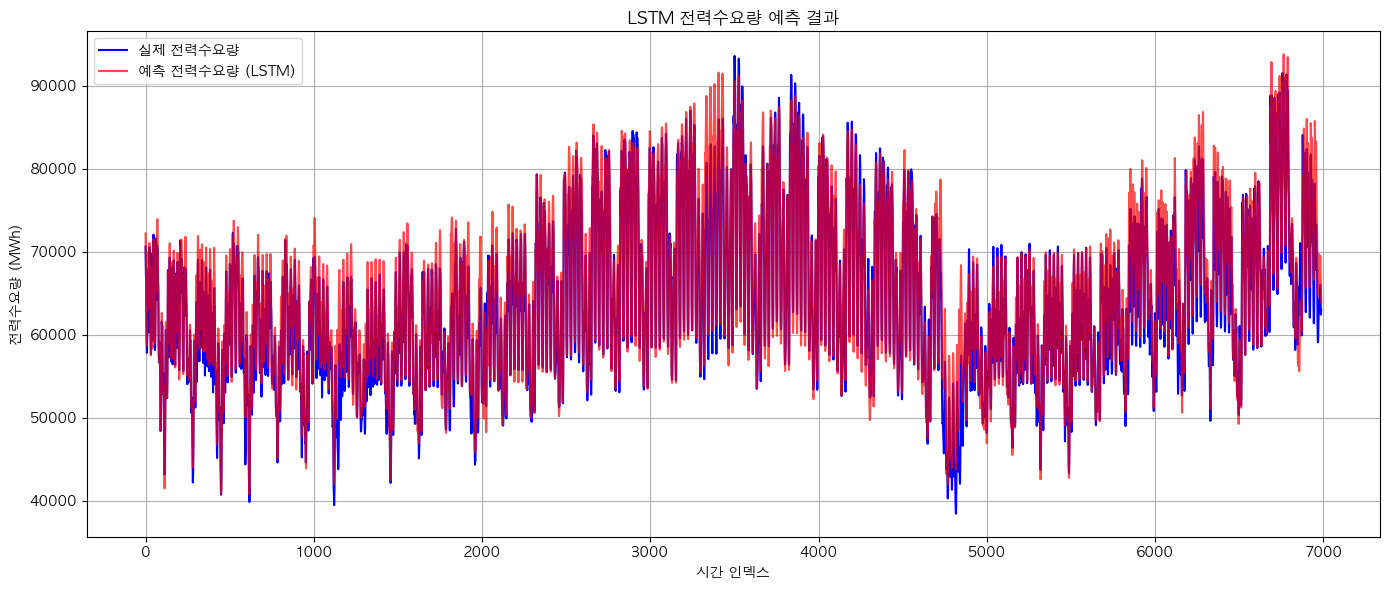

In [13]:
import matplotlib.pyplot as plt

# 한글 폰트 설정 (macOS용)
plt.rcParams['font.family'] = 'AppleGothic'   # macOS 한글 지원
plt.rcParams['axes.unicode_minus'] = False    # 마이너스 부호 깨짐 방지

# 시각화
plt.figure(figsize=(14, 6))

plt.plot(y_test_inv, label='실제 전력수요량', color='blue')
plt.plot(y_pred_inv, label='예측 전력수요량 (LSTM)', color='red', alpha=0.7)

plt.title("LSTM 전력수요량 예측 결과")
plt.xlabel("시간 인덱스")
plt.ylabel("전력수요량 (MWh)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


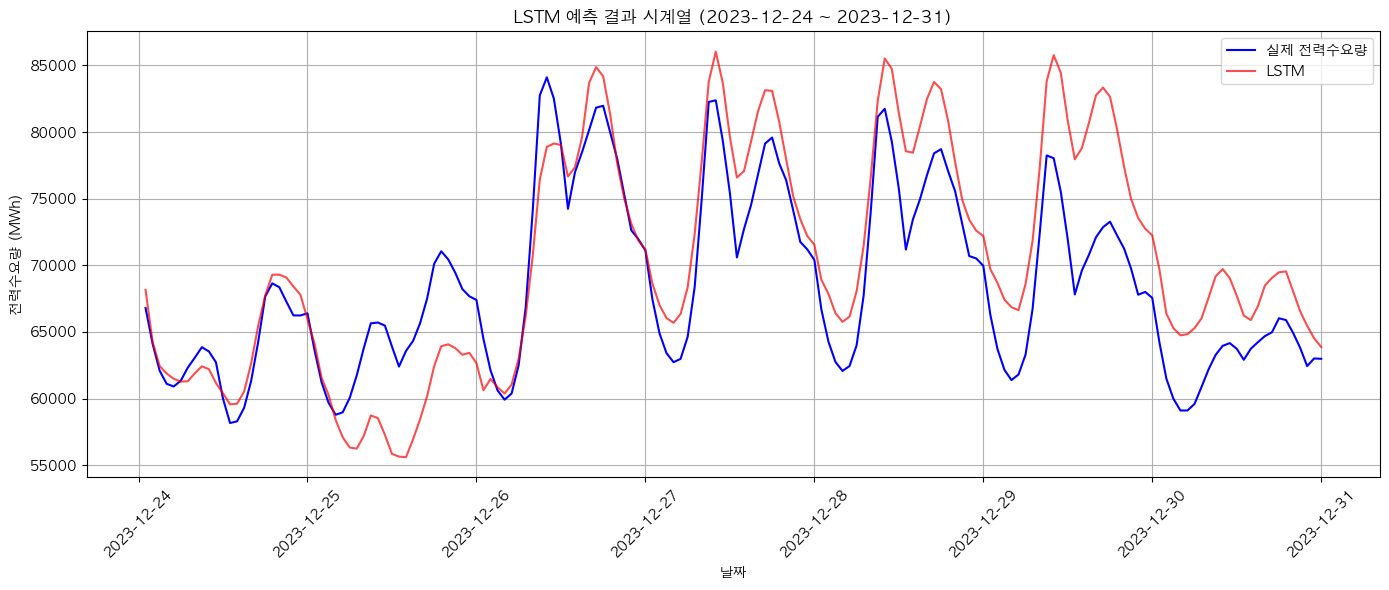

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# 1. 날짜 포함 원본 데이터 로드
df_full = pd.read_csv("./archive/final_merged.csv")

# 2. 날짜 열 변환
df_full["날짜"] = pd.to_datetime(df_full["날짜"], format="%Y.%m.%d %H:%M")

# 3. 날짜 시리즈 분할 (y_test 기준 20% 뒤쪽과 맞추기)
date_series = df_full["날짜"]
_, date_test = train_test_split(date_series, test_size=0.2, shuffle=False)
date_test = date_test.reset_index(drop=True)

# 4. 최근 168시간 추출 (LSTM 예측 구간)
date_recent = date_test[-168:]

# 5. 시각화 (LSTM 예측 결과 시리즈가 준비되어 있어야 함)
plt.figure(figsize=(14, 6))
plt.plot(date_recent, y_test_recent, label='실제 전력수요량', color='blue')
plt.plot(date_recent, y_pred_recent, label='LSTM', color='red', alpha=0.7)

plt.title("LSTM 예측 결과 시계열 (2023-12-24 ~ 2023-12-31)")
plt.xlabel("날짜")
plt.ylabel("전력수요량 (MWh)")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


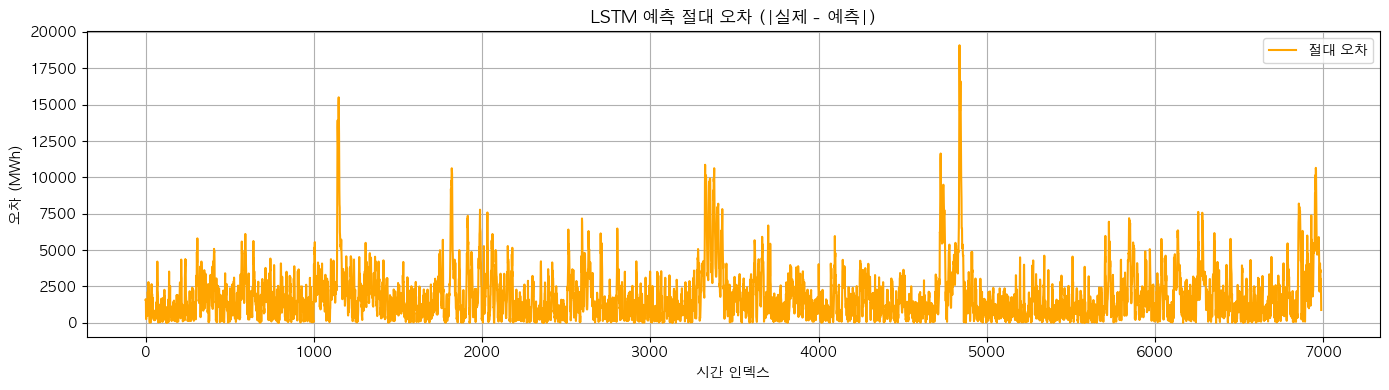

In [15]:
# 오차 계산
error = np.abs(y_test_inv - y_pred_inv)

# 시각화
plt.figure(figsize=(14, 4))
plt.plot(error, label='절대 오차', color='orange')
plt.title("LSTM 예측 절대 오차 (|실제 - 예측|)")
plt.xlabel("시간 인덱스")
plt.ylabel("오차 (MWh)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


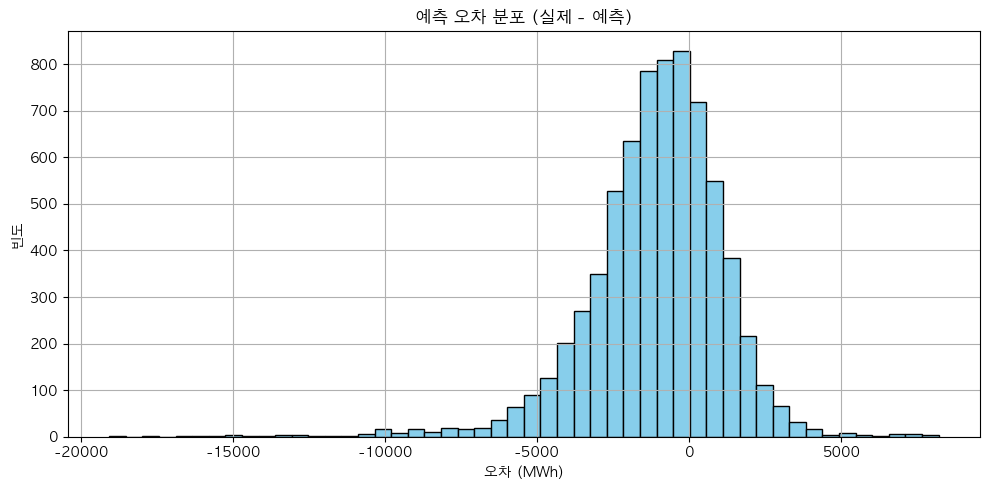

In [16]:
import matplotlib.pyplot as plt

# 한글 폰트 설정 (macOS 기준)
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

# 오차 계산
error = y_test_inv - y_pred_inv

# 히스토그램 시각화
plt.figure(figsize=(10, 5))
plt.hist(error, bins=50, color='skyblue', edgecolor='black')
plt.title("예측 오차 분포 (실제 - 예측)")
plt.xlabel("오차 (MWh)")
plt.ylabel("빈도")
plt.grid(True)
plt.tight_layout()
plt.show()


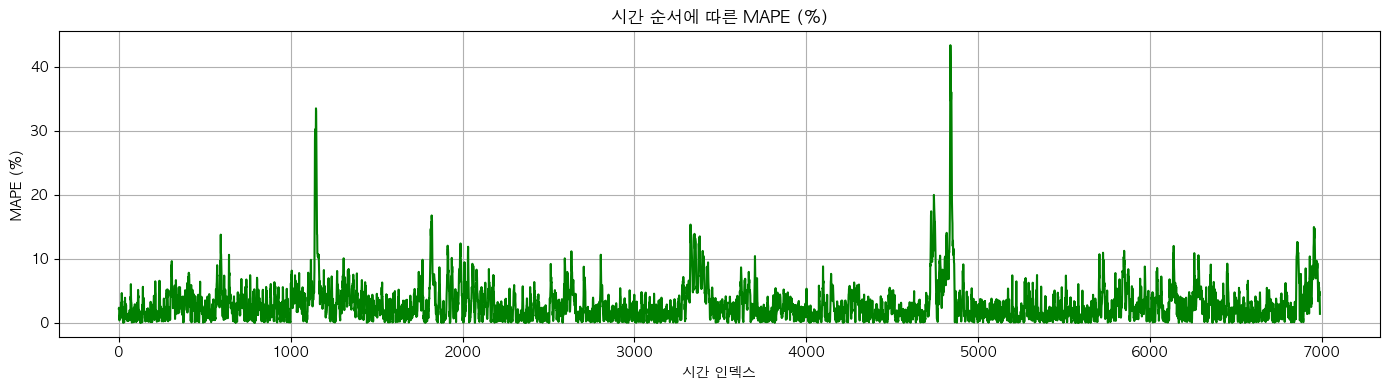

In [17]:
# MAPE 계산: 시간별 절대 오차 비율 (%)
mape_series = np.abs((y_test_inv - y_pred_inv) / y_test_inv) * 100

# 시각화
plt.figure(figsize=(14, 4))
plt.plot(mape_series, color='green')
plt.title("시간 순서에 따른 MAPE (%)")
plt.xlabel("시간 인덱스")
plt.ylabel("MAPE (%)")
plt.grid(True)
plt.tight_layout()
plt.show()
